# Uncertainty diagnostics for exported results

This notebook reads exported `.npy` prediction-interval results from `result/<project>/<model>/<dataset>/`. It accepts either a concrete result file or a project/model/dataset selector, so figures can be regenerated for any experiment.

The exporter stores four components. Flow CQR uses `(lower, point, upper, label)`, while OD-CQR, ACI, and ZeroCQR use `(point, lower, upper, label)`. The loader checks both conventions automatically; set `component_order` explicitly if a non-standard export is used.

In [38]:
from dataclasses import dataclass
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Match the typography and compact, publication-oriented styling in result.ipynb.
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

RESULT_ROOT = Path('/home/dy23a.fsu/st/result')
FIGURE_DIR = Path('/home/dy23a.fsu/st/result/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Preferred: give exact files (one or more). Paths may be absolute or relative to RESULT_ROOT.
RESULT_PATHS = [
    # 'Chi_OD_Calibration/pdr_reg_post/chicago_od_15min_bike/pdr_reg_post-chicago_od_15min_bike-zero_cqr_8bin-res.npy',
]

# Alternative: selectors resolve a single file within result/<project>/<model>/<dataset>.
# `pattern` can target a calibration variant; `latest=True` then selects its newest export.
SELECTIONS = [
    dict(project='NYC_OD', model='PDR_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*.npy', label='PDR'),
    
    dict(project='NYC_OD', model='AGCRN_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*.npy', label='AGCRN'),
]

# Keep notebook responsive for large OD tensors. Set None to use all valid cells.
MAX_SAMPLES = 1_000_000
RANDOM_SEED = 2026
SOURCE_NOMINAL_COVERAGE = 0.90  # coverage of the saved lower/upper interval
COMPONENT_ORDER = 'auto'        # 'auto', 'flow_cqr', or 'od_cqr'
SAVE_FIGURES = False


In [39]:
def discover_results(root=RESULT_ROOT):
    """Return every exported array with its project/model/dataset location."""
    rows = []
    for path in sorted(root.glob('*/*/*/*res*.npy')):
        rel = path.relative_to(root)
        rows.append(dict(project=rel.parts[0], model=rel.parts[1], dataset=rel.parts[2],
                         file=path.name, path=str(path), modified=pd.Timestamp(path.stat().st_mtime, unit='s')))
    return pd.DataFrame(rows)

def resolve_selection(selection, root=RESULT_ROOT):
    directory = root / selection['project'] / selection['model'] / selection['dataset']
    pattern = selection.get('pattern', '*res*.npy')
    matches = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not matches:
        raise FileNotFoundError(f'No result matched {directory / pattern}')
    return matches[-1], selection.get('label', f"{selection['model']} | {selection['dataset']}")

def requested_paths():
    chosen = []
    for item in RESULT_PATHS:
        path = Path(item)
        path = path if path.is_absolute() else RESULT_ROOT / path
        if not path.exists():
            raise FileNotFoundError(path)
        chosen.append((path, path.stem.replace('-res', '')))
    chosen.extend(resolve_selection(s) for s in SELECTIONS)
    if not chosen:
        raise ValueError('Add at least one path to RESULT_PATHS or one entry to SELECTIONS.')
    return chosen

@dataclass
class IntervalData:
    label: str
    path: Path
    point: np.ndarray
    lower: np.ndarray
    upper: np.ndarray
    target: np.ndarray
    horizon: np.ndarray
    order: str

def _order_score(point, lower, upper):
    finite = np.isfinite(point) & np.isfinite(lower) & np.isfinite(upper)
    if not finite.any():
        return -np.inf
    return np.mean((lower[finite] <= point[finite]) & (point[finite] <= upper[finite]))

def load_interval_result(path, label=None, component_order=COMPONENT_ORDER, max_samples=MAX_SAMPLES, seed=RANDOM_SEED):
    """Load a bounded random sample without materializing a large OD result tensor."""
    raw = np.load(path, mmap_mode='r')
    if raw.ndim < 2 or raw.shape[0] < 4:
        raise ValueError(f'{path.name} is not a four-component interval export; found shape {raw.shape}.')
    total = int(np.prod(raw.shape[1:]))
    rng = np.random.default_rng(seed)
    take = total if max_samples is None else min(total, int(max_samples))
    flat_idx = np.arange(total) if take == total else rng.choice(total, size=take, replace=False)

    # Compare the two exporter conventions using a small sampled slice.
    probe = flat_idx[:min(10_000, len(flat_idx))]
    c0, c1, c2 = (raw[i].reshape(-1)[probe] for i in range(3))
    candidates = {'flow_cqr': (c1, c0, c2), 'od_cqr': (c0, c1, c2)}
    if component_order == 'auto':
        component_order = max(candidates, key=lambda key: _order_score(*candidates[key]))
    if component_order not in candidates:
        raise ValueError("component_order must be 'auto', 'flow_cqr', or 'od_cqr'.")
    point_i, lower_i, upper_i = {'flow_cqr': (1, 0, 2), 'od_cqr': (0, 1, 2)}[component_order]
    point = np.asarray(raw[point_i].reshape(-1)[flat_idx], dtype=float)
    lower = np.asarray(raw[lower_i].reshape(-1)[flat_idx], dtype=float)
    upper = np.asarray(raw[upper_i].reshape(-1)[flat_idx], dtype=float)
    target = np.asarray(raw[3].reshape(-1)[flat_idx], dtype=float)
    valid = np.isfinite(point) & np.isfinite(lower) & np.isfinite(upper) & np.isfinite(target) & (upper >= lower)
    # In C-order, horizon advances after all later dimensions have been enumerated.
    horizon_size = raw.shape[2] if raw.ndim >= 3 else 1
    stride_after_horizon = int(np.prod(raw.shape[3:])) if raw.ndim >= 4 else 1
    horizon = (flat_idx // stride_after_horizon) % horizon_size
    return IntervalData(label or path.stem, Path(path), point[valid], lower[valid], upper[valid],
                        target[valid], horizon[valid], component_order)

available = discover_results()
print(f'Found {len(available)} exported .npy result files under {RESULT_ROOT}.')
available.head(10)


Found 1004 exported .npy result files under /home/dy23a.fsu/st/result.


,project,model,dataset,file,path,modified
0,Chi_OD,AGCRN_OD,chicago_od_15min_bike,AGCRN_OD-chicago_od_15min_bike-res.npy,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD/chic...,2026-07-19 09:14:23
1,Chi_OD,AGCRN_OD,chicago_od_15min_taxi,AGCRN_OD-chicago_od_15min_taxi-res.npy,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD/chic...,2026-07-17 21:35:58
2,Chi_OD,AGCRN_OD,chicago_od_15min_tnp,AGCRN_OD-chicago_od_15min_tnp-res.npy,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD/chic...,2026-07-18 20:15:42
3,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 07:57:38
4,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 12:54:22
5,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 07:57:24
6,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_aci_od_a...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 12:54:06
7,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_cqr_od_c...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-20 12:36:22
8,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_cqr_od_c...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-20 12:36:06
9,Chi_OD,AGCRN_OD_CQR,chicago_od_15min_bike,AGCRN_OD_CQR-chicago_od_15min_bike-od_cqr_od_s...,/home/dy23a.fsu/st/result/Chi_OD/AGCRN_OD_CQR/...,2026-07-21 07:57:08


In [40]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
MARKERS = ['^', 'o', 's', 'D', 'v', 'P']

def style_axis(ax, xlabel, ylabel, xpercent=False, ypercent=False):
    ax.set_xlabel(xlabel, fontsize=22, fontweight='bold', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=22, fontweight='bold', labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=18, direction='in', length=7, width=1.4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.grid(True, linestyle='--', linewidth=0.9, alpha=0.35, zorder=0)
    if xpercent:
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    if ypercent:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

def interval_score(lower, upper, target, alpha=1 - SOURCE_NOMINAL_COVERAGE):
    width = upper - lower
    return width + (2 / alpha) * np.maximum(lower - target, 0) + (2 / alpha) * np.maximum(target - upper, 0)

def calibration_curve(data, targets=np.linspace(.05, .99, 20)):
    center, half_width = (data.lower + data.upper) / 2, (data.upper - data.lower) / 2
    empirical = [np.mean((data.target >= center - half_width * (c / SOURCE_NOMINAL_COVERAGE)) &
                         (data.target <= center + half_width * (c / SOURCE_NOMINAL_COVERAGE))) for c in targets]
    return targets, np.asarray(empirical)

def selective_risk(data, coverages=np.linspace(.02, 1, 50)):
    mae = np.abs(data.target - data.point)
    ranking = np.argsort(interval_score(data.lower, data.upper, data.target))
    risk = [mae[ranking[:max(1, math.ceil(c * len(mae)))]].mean() for c in coverages]
    return coverages, np.asarray(risk), mae.mean()

def width_strata(data, bins=10):
    width = data.upper - data.lower
    edges = np.quantile(width, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    group = np.clip(np.digitize(width, edges[1:-1], right=True), 0, len(edges) - 2)
    x = np.arange(len(edges) - 1) + 1
    cov = np.array([np.mean((data.target[group == j] >= data.lower[group == j]) & (data.target[group == j] <= data.upper[group == j])) for j in range(len(x))])
    mae = np.array([np.mean(np.abs(data.target[group == j] - data.point[group == j])) for j in range(len(x))])
    return x, cov, mae


In [41]:
def plot_empirical_vs_target(datasets):
    fig, ax = plt.subplots(figsize=(6.4, 5.4))
    ax.plot([0, 1], [0, 1], '--', color='#666666', lw=2.5, label='Ideal calibration', zorder=1)
    for i, data in enumerate(datasets):
        x, y = calibration_curve(data)
        ax.plot(x, y, color=COLORS[i % len(COLORS)], marker=MARKERS[i % len(MARKERS)],
                markerfacecolor='white', markeredgewidth=1.5, markevery=2, ms=7, lw=3.2,
                label=data.label, zorder=3+i)
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=np.linspace(0, 1, 6), yticks=np.linspace(0, 1, 6))
    style_axis(ax, 'Target Coverage', 'Empirical Coverage')
    ax.legend(fontsize=13, loc='lower right', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_selective_regression(datasets):
    fig, ax = plt.subplots(figsize=(6.7, 5.4))
    for i, data in enumerate(datasets):
        x, risk, nonselective = selective_risk(data)
        color = COLORS[i % len(COLORS)]
        ax.plot(x, risk, color=color, marker=MARKERS[i % len(MARKERS)], markerfacecolor='white',
                markeredgewidth=1.4, markevery=5, ms=7, lw=3.2, label=f'{data.label}: IS-guided')
        ax.axhline(nonselective, color=color, ls='--', lw=1.8, alpha=.75, label=f'{data.label}: non-selective')
    ax.set(xlim=(0, 1), xticks=np.linspace(0, 1, 6))
    style_axis(ax, 'Coverage retained', 'Risk (MAE)', xpercent=True)
    ax.legend(fontsize=11.5, loc='upper left', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_conditional_diagnostics(datasets):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharex=True)
    for i, data in enumerate(datasets):
        x, coverage, mae = width_strata(data)
        kwargs = dict(color=COLORS[i % len(COLORS)], marker=MARKERS[i % len(MARKERS)],
                      markerfacecolor='white', markeredgewidth=1.3, ms=6.5, lw=2.8, label=data.label)
        axes[0].plot(x, coverage, **kwargs)
        axes[1].plot(x, mae, **kwargs)
    axes[0].axhline(SOURCE_NOMINAL_COVERAGE, color='#555555', ls='--', lw=2, label='Nominal coverage')
    for ax in axes:
        ax.set_xticks(np.arange(1, 11, 2))
        ax.set_xlim(.7, 10.3)
    axes[0].set_ylim(0, 1.03)
    style_axis(axes[0], 'Interval-width decile (narrow → wide)', 'Empirical Coverage', ypercent=True)
    style_axis(axes[1], 'Interval-width decile (narrow → wide)', 'MAE')
    axes[0].legend(fontsize=11.5, loc='best', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_horizon_diagnostics(datasets):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8))
    for i, data in enumerate(datasets):
        h = np.unique(data.horizon)
        coverage = [np.mean((data.target[data.horizon == k] >= data.lower[data.horizon == k]) & (data.target[data.horizon == k] <= data.upper[data.horizon == k])) for k in h]
        mae = [np.mean(np.abs(data.target[data.horizon == k] - data.point[data.horizon == k])) for k in h]
        kwargs = dict(color=COLORS[i % len(COLORS)], marker=MARKERS[i % len(MARKERS)], markerfacecolor='white', markeredgewidth=1.3, ms=6.5, lw=2.8, label=data.label)
        axes[0].plot(h + 1, coverage, **kwargs)
        axes[1].plot(h + 1, mae, **kwargs)
    axes[0].axhline(SOURCE_NOMINAL_COVERAGE, color='#555555', ls='--', lw=2, label='Nominal coverage')
    style_axis(axes[0], 'Forecast horizon', 'Empirical Coverage', ypercent=True)
    style_axis(axes[1], 'Forecast horizon', 'MAE')
    axes[0].legend(fontsize=11.5, loc='best', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig


In [42]:
datasets = [load_interval_result(path, label) for path, label in requested_paths()]
summary = pd.DataFrame([{
    'label': d.label, 'sampled cells': len(d.target), 'component order': d.order,
    'MAE': np.mean(np.abs(d.target - d.point)),
    'PICP @ saved interval': np.mean((d.target >= d.lower) & (d.target <= d.upper)),
    'MPIW @ saved interval': np.mean(d.upper - d.lower),
} for d in datasets])
display(summary)


,label,sampled cells,component order,MAE,PICP @ saved interval,MPIW @ saved interval
0,PDR,1000000,od_cqr,0.320490,0.951182,1.616577
1,AGCRN,1000000,od_cqr,0.279188,0.950970,1.622593


## 1. Empirical coverage vs. target coverage

Run this cell independently after the shared data-loading cell. Add another `IntervalData` item to `datasets` to compare additional results.


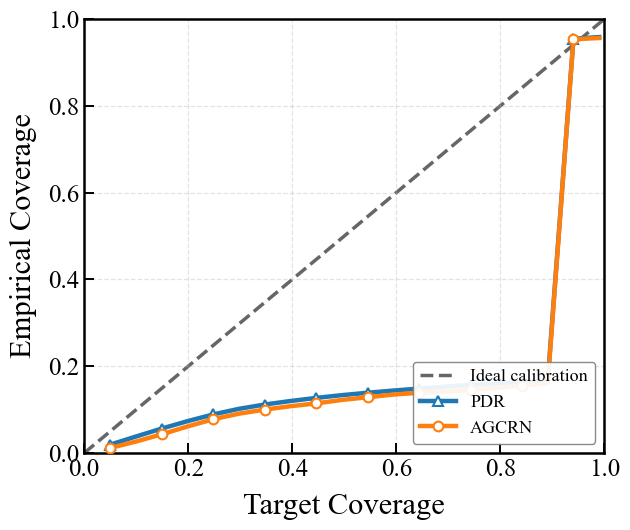

In [43]:
fig_calibration = plot_empirical_vs_target(datasets)
if SAVE_FIGURES:
    fig_calibration.savefig(FIGURE_DIR / 'empirical_vs_target_coverage.pdf', bbox_inches='tight')
plt.show()


## 2. Selective regression: MAE vs. coverage by IS score

The retained subset is formed by sorting examples from lowest to highest interval score.


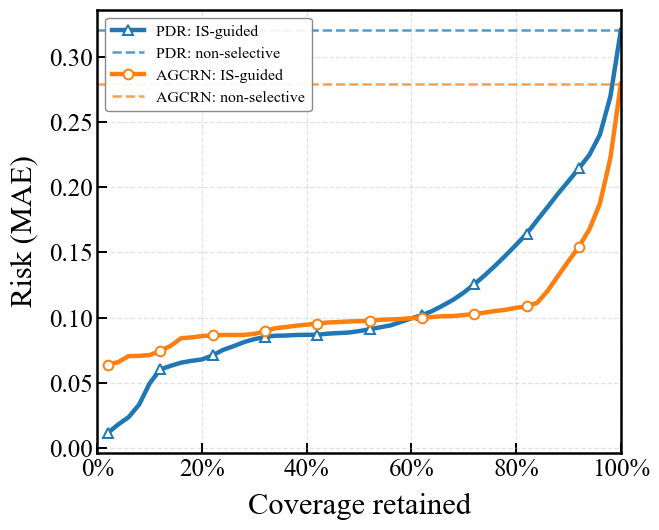

In [44]:
fig_selective = plot_selective_regression(datasets)
if SAVE_FIGURES:
    fig_selective.savefig(FIGURE_DIR / 'selective_mae_by_is.pdf', bbox_inches='tight')
plt.show()


## 3. Conditional calibration and uncertainty ranking

This figure checks calibration within interval-width strata and whether wider predicted intervals correspond to higher point-prediction error.


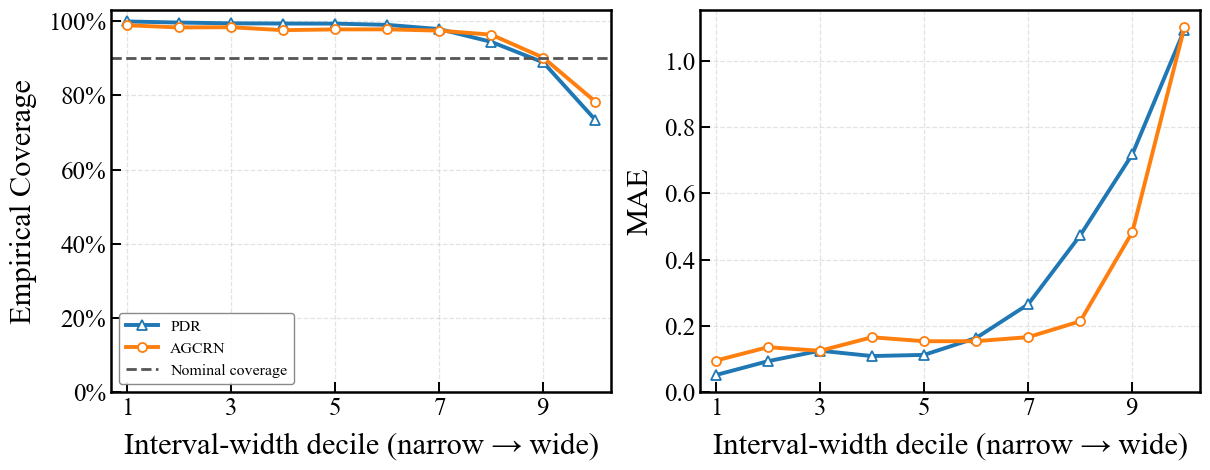

In [45]:
fig_conditional = plot_conditional_diagnostics(datasets)
if SAVE_FIGURES:
    fig_conditional.savefig(FIGURE_DIR / 'conditional_width_diagnostics.pdf', bbox_inches='tight')
plt.show()


## 4. Horizon-wise uncertainty diagnostics

Use this independently to identify forecast horizons where aggregate coverage or MAE hides degradation.


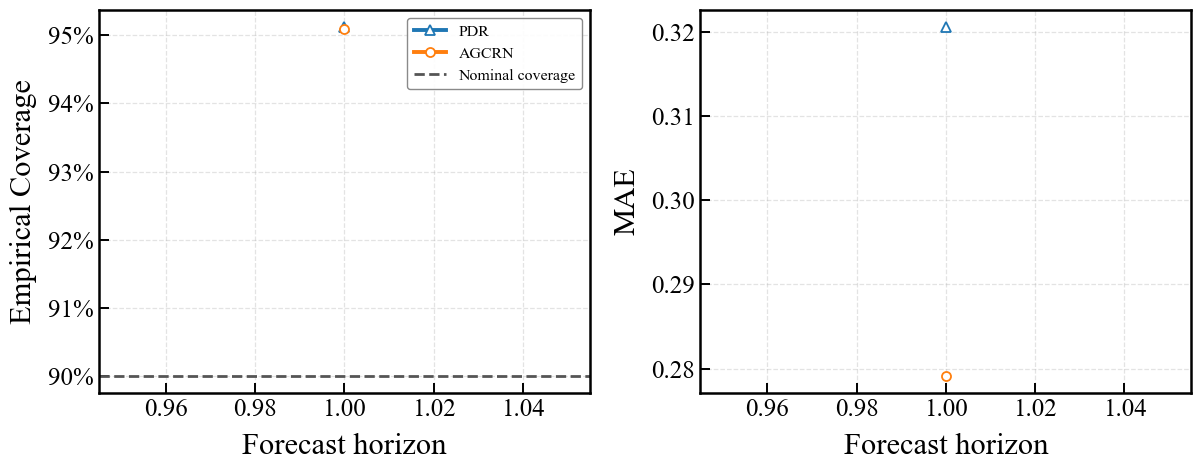

In [46]:
fig_horizon = plot_horizon_diagnostics(datasets)
if SAVE_FIGURES:
    fig_horizon.savefig(FIGURE_DIR / 'horizon_diagnostics.pdf', bbox_inches='tight')
plt.show()


### Reading the diagnostics

- **Empirical vs. target coverage:** proximity to the diagonal indicates calibrated uncertainty; a curve below it under-covers.
- **Selective regression:** a lower IS-guided curve at low retained coverage means the interval score identifies the cases where point predictions are most reliable. The dashed line is the expected MAE without selection.
- **Width-decile diagnostic:** coverage should stay near the nominal line across deciles, while MAE should generally rise toward wider predicted intervals. This jointly tests conditional calibration and whether the uncertainty estimate ranks difficulty.
- **Horizon diagnostic:** a declining coverage curve or rising MAE exposes forecast horizons where a globally acceptable aggregate result conceals failure.